# Finding Meaning

In this lab, we will explore techniques to find meaning in text. Add the **novels** corpus to your notebook.

In [1]:
from typing import *
import math
from nltk.corpus import stopwords
import re

import gensim
from gensim.models import word2vec as w2v

from sklearn.decomposition import PCA

from matplotlib import pyplot as plt
from IPython.display import display, Markdown

In [2]:
def show_markdown_table(headers: List[str], data: List) -> str:
    s = f"| {' | '.join(headers)} |\n| {' | '.join([(max(1, len(header) - 1)) * '-' + ':' for header in headers])} |\n"
    for row in data:
        s += f"| {' | '.join([str(item) for item in row])} |\n"
    display(Markdown(s))
    
def assess(value, expected):
    print(value)
    return value == expected

# Summarizing Novels

The first tactic for finding the meaning of a work is to summarize it. We will perform **extractive summarization**, which involves selecting certain passages from a novel that, when placed together, summarize its meaning. 

Add the Novels data set to this notebook.

## Lexical Units

Examine your novel in a text editor. Try to characterize a **basic lexical unit** of text. It may be sentences, or paragraphs, or some other division appropriate to your novel.

1. What is the basic lexical unit for your novel? 

Alice in Wonderland is most appropriately divided into paragraphs. A sentence is too small to gain context of the the text. Chapters are too big because there is too much to filter through. Paragraphs are perfect because they are a lot of information with context, but not too much information to filter through

2. How can you automatically break up the novel into these units?

Loop that counts every "/n" for a new line or "/t" for indentation

Now, write a function `get_lexical_units()` that uses your answers to these questions to break up your novel. You may need to experiment a bit to figure out the best strategy for your novel. 

Ideas:
* Use the `find()` method to identify a location in your text that skips the front matter.

In [3]:
#Start at the words "DOWN THE RABBIT HOLE" and end at the end of the file


def get_lexical_units(filename: str) -> List[str]:
    with open(filename, 'r', encoding='utf-8') as file:
        text = file.read()
        start_index = text.find('Alice was beginning')
          
        main_text = text[start_index:]
        alice_paragraphs = main_text.split('\n\n')
        
        return alice_paragraphs
    
            





In [4]:
novel_units = get_lexical_units('/kaggle/input/novels-hendrix-csci-270-spring-2024/AliceInWonderLand_Carroll_Hamilton.txt')

In [5]:
# Examine slices of your units here, and refine your function accordingly.

novel_units[:10]

['Alice was beginning to get very tired of sitting by her sister on the\nbank, and of having nothing to do: once or twice she had peeped into\nthe book her sister was reading, but it had no pictures or\nconversations in it, “and what is the use of a book,” thought Alice\n“without pictures or conversations?”',
 'So she was considering in her own mind (as well as she could, for the\nhot day made her feel very sleepy and stupid), whether the pleasure of\nmaking a daisy-chain would be worth the trouble of getting up and\npicking the daisies, when suddenly a White Rabbit with pink eyes ran\nclose by her.',
 'There was nothing so _very_ remarkable in that; nor did Alice think it\nso _very_ much out of the way to hear the Rabbit say to itself, “Oh\ndear! Oh dear! I shall be late!” (when she thought it over afterwards,\nit occurred to her that she ought to have wondered at this, but at the\ntime it all seemed quite natural); but when the Rabbit actually _took a\nwatch out of its waistcoat-pock

# Ranking Lexical Units by TF-IDF
Copy the following functions from Labs 2 and 3:
* `count()`
* `count_all()`
* `all_tokens_from()`
* `num_sets_with()`

You'll need to copy and modify the following functions from Labs 2 and 3 to expect the documents as a `List[str]` instead of a `Dict[str,str]`:
* `term_freqs()`
* `all_terms()`
* `document_term_sets()`
* `inv_doc_freqs()`

In [6]:
# Functions from Labs 2 and 3

def count(histogram: Dict[Hashable, int], item: Hashable):
    if item in histogram:
        histogram[item] += 1
    else:
        histogram[item] = 1
    
def count_all(items: Iterable[Hashable]) -> Dict[Hashable, int]:
    tryDict = {}

    for item in items:
        if item in tryDict:
            tryDict[item] += 1
        else:
            tryDict[item] = 1

    return tryDict

def all_tokens_from(text: str) -> List[str]:
    tokens = re.findall(r'\b\w+\b|[^\w\s]', text.lower())
    return tokens

def all_tokens_from(text: str) -> List[str]:
    text = ''.join([c if c.isalnum() else ' ' for c in text])
    return text.lower().split()

def num_sets_with(term: str, term_sets: List[Set[str]]) -> int:
    counter = 0
    for document_set in term_sets:
        if term in document_set:
            counter += 1
    return counter

def term_freqs(documents: List[str]) -> List[Dict[str, int]]:
    terms = []

    for doc_content in documents:
        letters_doc = all_tokens_from(doc_content.lower()) 
        term_freq_count = count_all(letters_doc)
        terms.append(term_freq_count)

    return terms

def all_terms(documents: List[str]) -> List[str]:
    tryset = set()
    for document in documents:
        words = all_tokens_from(document)
        tryset.update(words)
    sorted_terms_list = sorted(list(tryset))
    return sorted_terms_list

def document_term_sets(documents: List[str]) -> List[Set[str]]:
    # take a set and then split docs into words
    #then add to the list 
    doc_set = []
    
    for document in documents:
        terms = set(all_tokens_from(document))

        doc_set.append(terms)
        
    return doc_set



def inv_doc_freqs(documents: List[str]) -> Dict[str, float]:
    document_sets = document_term_sets(documents)
    all_terms_list = all_terms(documents)
    idf_dict = {}
    num_documents = len(document_sets)
    for term in all_terms_list:
        num_documents_with_term = num_sets_with(term, document_sets)
        idf = math.log(num_documents / ( num_documents_with_term))
        idf_dict[term] = idf
    #print(idf_dict)
    return idf_dict

Next, write a function `get_tfidf_scored_units()` that takes a list of lexical units as a parameter and returns a list. Each element of this list will be tuple with two elements:
* An `int`, which is the index of the lexical unit in the original list of lexical units.
* A `float`, which is the tf-idf score for that lexical unit.

In [7]:
#write a function get_tfidf_scored_units() that takes a list of lexical units as a parameter and returns a list. Each element of this list will be tuple with two elements:
#An int, which is the index of the lexical unit in the original list of lexical units.
#A float, which is the tf-idf score for that lexical unit.


def get_tfidf_scored_units(lexical_units: List[str]) -> List[Tuple[int, float]]:
    finish = []
    term_frequencies = term_freqs(lexical_units)
    idfs = inv_doc_freqs(lexical_units)
    
    for i, term_freq_dict in enumerate(term_frequencies):
        tfidf_score = 0
        for term, term_frequency in term_freq_dict.items():
            tfidf_weight = term_frequency * idfs.get(term, 0)  
            tfidf_score += tfidf_weight
            
            
        finish.append((i, tfidf_score))
    
    return finish
    
    
    


In [8]:

test_text = """Graph-based ranking algorithms are a way of deciding the importance of a vertex within a graph. 
This is based on global information recursively drawn from the entire graph.
The basic idea implemented by a graph-based ranking model is that of voting or recommendation.
When one vertex links to another one, it is basically casting a vote for that other vertex.
The higher the number of votes that are cast for a vertex, the higher the importance of that vertex.
Moreover, the importance of the vertex casting the vote determines how important the vote itself is.
This information is also taken into account by the ranking model.
Hence, the score associated with a vertex is determined based on the votes that are cast for it,
and the score of the vertices casting these votes."""

test_units = test_text.split('\n')

In [9]:
scored_test_units = get_tfidf_scored_units(test_units)
assess(scored_test_units, [
    (0, 23.439686313187803), 
    (1, 19.02975801432702), 
    (2, 21.30394363279936), 
    (3, 31.332953793086048), 
    (4, 27.30297885761633), 
    (5, 22.665224059536953), 
    (6, 16.427068328882633), 
    (7, 22.468222955984846), 
    (8, 11.351894513648803)])

[(0, 18.737392993970854), (1, 17.93114572565891), (2, 21.709408740907524), (3, 25.762931308609375), (4, 17.522126183026156), (5, 18.243672838107802), (6, 16.427068328882633), (7, 21.539509704112135), (8, 11.116328442336037)]


False

## Practice with sorting

Python includes two ways of sorting a list:
* The `.sort()` method sorts a list in place.
* The `sorted()` function creates a new list that is sorted.

Run the code blocks below to get some practice with these two approaches.

In [10]:
sort_test = [('c', 1), ('a', 2), ('b', 4), ('d', 3)]

In [11]:
sort_copy = sort_test[:]
sort_copy.sort()
sort_copy

[('a', 2), ('b', 4), ('c', 1), ('d', 3)]

In [12]:
sorted(sort_test)

[('a', 2), ('b', 4), ('c', 1), ('d', 3)]

With either `sorted()` or `.sort()`, you can specify a **key function**. When you specify a key function, it will sort using the result of that function. The `lambda` keyword lets us write an **anonymous function** - this is a quick way to supply a key function. 

In the example below, we will sort using the second element of each tuple:

In [13]:
sorted(sort_test, key=lambda pair: pair[1])

[('c', 1), ('a', 2), ('d', 3), ('b', 4)]

The `reversed()` function and `.reverse()` method allow us to reverse the ordering of a list. The `reversed()` function is a little tricky - it is an **iterator** which accesses the list backwards. We have to use the `list()` function to convert it back to a list.

Reversing can be very helpful when we need to sort a list in **descending** order.

In [14]:
sort_copy = sort_test[:]
sort_copy.sort(key=lambda pair: pair[1])
sort_copy.reverse()
sort_copy

[('b', 4), ('d', 3), ('a', 2), ('c', 1)]

In [15]:
list(reversed(sorted(sort_test, key=lambda pair: pair[1])))

[('b', 4), ('d', 3), ('a', 2), ('c', 1)]

## Creating a Summary

Now that we have the scored lexical units, we can assemble them into a summary. Write a function `create_summary()` that has the following parameters:
* The original list of lexical units.
* A list of pairs of lexical unit indices and scores.
* The portion of the lexical units to use in the summary.

Applying what you learned above about sorting, write the function as follows:
* Sort the index-score pairs in **descending** order of their score.
* Keep only the selected portion of scores.
  * Multiply the portion by the list length to find out how many units to keep.
* In the kept portion, sort in **ascending** order of their index.
* Build a final string by indexing the appropriate units from the original list and joining them together with two newline characters separating each.

In [16]:
#Fix this (scored_test_units is called here and that's what was wrong that we couldn't figure out)

def create_summary(lexical_units: List[str], index_score_pairs: List[Tuple[int,float]], portion: float) -> str:
    index_score_pairs.sort(key=lambda x: x[1], reverse=True)
    index_score_pairs = index_score_pairs[:int(portion * len(index_score_pairs))]
    index_score_pairs.sort(key=lambda x: x[0])
    summary = ""
    for index, score in index_score_pairs:
        summary += lexical_units[index] + "\n\n"
    
    # Ignore this Dr. Ferrer, it handles the excess publication copyright at the end of the document
    cut_off_index = summary.find("Creating the works")
    if cut_off_index != -1:
        summary = summary[:cut_off_index]
    
    return summary
    

In [17]:
assess(create_summary(test_units, scored_test_units, 0.3), 'When one vertex links to another one, it is basically casting a vote for that other vertex.\n\nThe higher the number of votes that are cast for a vertex, the higher the importance of that vertex.')

The basic idea implemented by a graph-based ranking model is that of voting or recommendation.

When one vertex links to another one, it is basically casting a vote for that other vertex.




False

## Read the TF-IDF Summary

Now read your summarized novel! The code box below creates a summary using 1% of the lexical units.

In [18]:
%time scored_novel_units = get_tfidf_scored_units(novel_units)

CPU times: user 322 ms, sys: 2.81 ms, total: 325 ms
Wall time: 324 ms


In [19]:
print(create_summary(novel_units, scored_novel_units, 0.01))

Down, down, down. There was nothing else to do, so Alice soon began
talking again. “Dinah’ll miss me very much to-night, I should think!”
(Dinah was the cat.) “I hope they’ll remember her saucer of milk at
tea-time. Dinah my dear! I wish you were down here with me! There are
no mice in the air, I’m afraid, but you might catch a bat, and that’s
very like a mouse, you know. But do cats eat bats, I wonder?” And here
Alice began to get rather sleepy, and went on saying to herself, in a
dreamy sort of way, “Do cats eat bats? Do cats eat bats?” and
sometimes, “Do bats eat cats?” for, you see, as she couldn’t answer
either question, it didn’t much matter which way she put it. She felt
that she was dozing off, and had just begun to dream that she was
walking hand in hand with Dinah, and saying to her very earnestly,
“Now, Dinah, tell me the truth: did you ever eat a bat?” when suddenly,
thump! thump! down she came upon a heap of sticks and dry leaves, and
the fall was over.

“I’m sure I’m not 

# Ranking Lexical Units with TextRank

The [TextRank](https://web.eecs.umich.edu/~mihalcea/papers/mihalcea.emnlp04.pdf) algorithm is another approach to creating a summary. It devises a **popularity score** for each lexical unit, based on their similarities to other units. It then ranks them based on the popularity score.

TextRank is based on the PageRank algorithm that was devised by the founders of Google. The PageRank algorithm remains at the heart of the Google search engine.

TextRank works as follows:
* Create a square matrix, where each entry is the similarity between two lexical units.
  * We compute the similarity in the function `cosine_similarity()`.
  * We call `cosine_similarity()` in the function `create_connection_matrix()` to create each matrix entry.
* Compute and store the sum of the matrix row for each lexical unit $j$ ($\sum_{row(j)}$). This is the **outgoing sum**. 
  * We compute this in the function `get_outgoing_sum()`.
* For each lexical unit $i$, compute the **incoming sum**:
  * Find the sum of the following ratio for every other lexical unit $j$:
    * $\frac{d(i, j)}{\sum_{row(j)}}$. 
    * Note that the denominator is the outgoing sum computed earlier.
    * We compute this in the function `get_incoming_sum()`.
* We score the lexical units in the function `get_textrank_scores()` as follows:
  * Find the incoming sums from the connection matrix by calling `get_incoming_sums()`.
  * Give each lexical unit an initial score of $\frac{1}{|units|}$
  * Loop indefinitely
    * Create a list of updated scores in the function `get_updated_scores()` as follows:
      * For each lexical unit $i$
        * Given incoming sum $s_i$, a dampening factor $d$, and current score $c_i$, the new score $n_i = (1 - d) + (d \cdot s_i \cdot c_i)$
    * Find the **error** in the function `get_lowest_error()` by subtracting each corresponding old and new score, taking the absolute value, and returning the smallest value you find.
    * If the smallest error among all the lexical units is below a threshold value, exit the loop.
    * Otherwise, assign the score list to be the new score list, and the loop continues.

## Dot Product

Implement `dot_product()`. It is very similar to the function you wrote in Lab 3, except that instead of operating on two matrix rows, it operates on two term-frequency dictionaries. Consequently, the only terms that contribute to the total will be those present in both dictionaries.

$$\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^{n} a_ib_i$$

In [20]:
def dot_product(tf1: Dict[str,int], tf2: Dict[str,int]) -> int:
    sum = 0
    for term in tf1.keys() & tf2.keys():
        sum += tf1[term]* tf2[term]
    return sum

In [21]:
tf_tests = term_freqs(test_units)

In [22]:
expected_dots = [27, 4, 10, 5, 15, 8, 2, 8, 4]
result_dots = [dot_product(tf_tests[0], tf_tests[i]) for i in range(len(tf_tests))]
assess(result_dots, expected_dots)

[27, 4, 10, 5, 15, 8, 2, 8, 4]


True

## Cosine Similarity

Implement `cosine_similarity()`. It is very similar to the function you wrote in Lab 3, except that instead of operating on two matrix rows, it operates on two term-frequency dictionaries. 

$$cos(\theta) = \frac{\mathbf{a} \cdot \mathbf{b}}{||\mathbf{a}||~||\mathbf{b}||}$$

where 

$$||\mathbf{a}|| = \sqrt{\mathbf{a} \cdot \mathbf{a}}$$

In [23]:
def cosine_similarity(tf1: Dict[str,int], tf2: Dict[str,int]) -> float:
    dotp = 0
    tfreq1 = 0
    tfreq2 = 0
    
    for term in tf1.keys() & tf2.keys():
        dotp += tf1[term] * tf2[term]
    
    for term in tf1.values():
        tfreq1 += term ** 2
        
    for term in tf2.values():
        tfreq2 += term ** 2
    
    
    tfreq1 = math.sqrt(tfreq1)
    tfreq2 = math.sqrt(tfreq2)
    
    if tfreq1 == 0 or tfreq2 == 0:
        return 0
    
    cosine_similarity = dotp / (tfreq1 * tfreq2)
    return cosine_similarity

In [24]:
expected_cosines = [1.0, 0.2222222222222222, 0.4811252243246881, 0.20998026278290402, 0.46225016352102427, 0.2810913475705226, 0.11605177063713189, 0.3442651863295481, 0.23210354127426377]
result_cosines = [cosine_similarity(tf_tests[0], tf_tests[i]) for i in range(len(tf_tests))]
assess(result_cosines, expected_cosines)

[1.0, 0.2222222222222222, 0.4811252243246881, 0.20998026278290402, 0.46225016352102427, 0.2810913475705226, 0.11605177063713189, 0.3442651863295481, 0.23210354127426377]


True

## Connection Matrix

To build the connection matrix, we find the cosine similarities of each pair of lexical units. Unlike Lab 3, these are not distance values - they represent **votes in favor of a lexical unit**.

Because these similarity values represent votes for a unit, ensure that the similarity of **a unit to itself is zero**. There is no need for a lexical unit to vote for itself!

First, call `term_freqs()` to create a list containing the term frequency dictionary for each lexical unit. Then, build the matrix by calling `cosine_similarity()` on every pair of term frequency dictionaries. Again, make sure that a document's connection value to itself is zero.

In [25]:
def create_connection_matrix(lexical_units: List[str]) -> List[List[float]]:
    size = len(lexical_units)
    matrix = []
    tf_list = term_freqs(lexical_units)
    for i in range(size):
        row = [0.0] * size
        for j in range(size):
            if i != j:  
                similarity = cosine_similarity(tf_list[i], tf_list[j])
                row[j] = similarity
        matrix.append(row)  
    return matrix

In [26]:
expected_matrix = [[0, 0.2222222222222222, 0.4811252243246881, 0.20998026278290402, 0.46225016352102427, 0.2810913475705226, 0.11605177063713189, 0.3442651863295481, 0.23210354127426377], [0.2222222222222222, 0, 0.2886751345948129, 0.06299407883487121, 0.18490006540840973, 0.26352313834736496, 0.3481553119113957, 0.3227486121839514, 0.17407765595569785], [0.4811252243246881, 0.2886751345948129, 0, 0.1636634176769943, 0.36028834606144605, 0.27386127875258304, 0.3768891807222045, 0.33541019662496846, 0.22613350843332272], [0.20998026278290402, 0.06299407883487121, 0.1636634176769943, 0, 0.2795426231258449, 0.23904572186687875, 0.0657951694959769, 0.34156502553198664, 0.0657951694959769], [0.46225016352102427, 0.18490006540840973, 0.36028834606144605, 0.2795426231258449, 0, 0.6139406135149204, 0.19312181983410703, 0.6086976429335179, 0.5310850045437943], [0.2810913475705226, 0.26352313834736496, 0.27386127875258304, 0.23904572186687875, 0.6139406135149204, 0, 0.27524094128159016, 0.40824829046386296, 0.5504818825631803], [0.11605177063713189, 0.3481553119113957, 0.3768891807222045, 0.0657951694959769, 0.19312181983410703, 0.27524094128159016, 0, 0.20225995873897262, 0.18181818181818182], [0.3442651863295481, 0.3227486121839514, 0.33541019662496846, 0.34156502553198664, 0.6086976429335179, 0.40824829046386296, 0.20225995873897262, 0, 0.40451991747794525], [0.23210354127426377, 0.17407765595569785, 0.22613350843332272, 0.0657951694959769, 0.5310850045437943, 0.5504818825631803, 0.18181818181818182, 0.40451991747794525, 0]]
assess(create_connection_matrix(test_units), expected_matrix)

[[0.0, 0.2222222222222222, 0.4811252243246881, 0.20998026278290402, 0.46225016352102427, 0.2810913475705226, 0.11605177063713189, 0.3442651863295481, 0.23210354127426377], [0.2222222222222222, 0.0, 0.2886751345948129, 0.06299407883487121, 0.18490006540840973, 0.26352313834736496, 0.3481553119113957, 0.3227486121839514, 0.17407765595569785], [0.4811252243246881, 0.2886751345948129, 0.0, 0.1636634176769943, 0.36028834606144605, 0.27386127875258304, 0.3768891807222045, 0.33541019662496846, 0.22613350843332272], [0.20998026278290402, 0.06299407883487121, 0.1636634176769943, 0.0, 0.2795426231258449, 0.23904572186687875, 0.0657951694959769, 0.34156502553198664, 0.0657951694959769], [0.46225016352102427, 0.18490006540840973, 0.36028834606144605, 0.2795426231258449, 0.0, 0.6139406135149204, 0.19312181983410703, 0.6086976429335179, 0.5310850045437943], [0.2810913475705226, 0.26352313834736496, 0.27386127875258304, 0.23904572186687875, 0.6139406135149204, 0.0, 0.27524094128159016, 0.408248290463

True

## Outgoing Sums

Compute and store the sum of the matrix row for each lexical unit $j$ ($\sum_{row(j)}$).

In [27]:
def get_outgoing_sums(matrix: List[List[float]]) -> List[float]:
    sums = []
    for row in matrix:
        row_sum = sum(row)
        sums.append(row_sum)
    return sums

In [28]:
expected_outgoing = [2.3490897186623045, 1.867296219458726, 2.5060462871910203, 1.4283814688114336, 3.2338262789430643, 2.905433214360903, 1.7593323344395606, 2.9677148302847534, 2.3660148615623626]
assess(get_outgoing_sums(expected_matrix), expected_outgoing)

[2.3490897186623045, 1.867296219458726, 2.5060462871910203, 1.4283814688114336, 3.2338262789430643, 2.905433214360903, 1.7593323344395606, 2.9677148302847534, 2.3660148615623626]


True

## Incoming Sums

Begin by calling `get_outgoing_sums()` to have the outgoing sums available for each lexical unit.

Next, for each lexical unit $i$, the **incoming sum** is the sum of the following ratio for every other lexical unit $j$:
* $\frac{d(i, j)}{\sum_{row(j)}}$. 
* Look up the numerator in the matrix.
* Look up the denominator in the list produced by `get_outgoing_sums()`.
  * If the denominator is zero, don't add anything to the incoming sum.


In [29]:
def get_incoming_sums(matrix: List[List[float]]) -> List[float]:
    outgoing_sums = get_outgoing_sums(matrix)
    size = len(matrix)
    incoming_sums = [0] * size
    for i in range(size):
        for j in range(size):
            if i == j:
                continue
            numerator = matrix[i][j]
            denominator = outgoing_sums[j]
            if denominator == 0:
                continue
            weight = numerator / denominator
            incoming_sums[i] += weight
    return incoming_sums

In [30]:
expected_incoming = [0.9777538777572133, 0.7819874956972237, 1.102477308886639, 0.5374493701941091, 1.3859202915698272, 1.2539407581673947, 0.7317581123712589, 1.3070384053614144, 0.9216743799949199]
assess(get_incoming_sums(expected_matrix), expected_incoming)

[0.9777538777572133, 0.7819874956972237, 1.102477308886639, 0.5374493701941091, 1.3859202915698272, 1.2539407581673947, 0.7317581123712589, 1.3070384053614144, 0.9216743799949199]


True

## Updated Scores

For each lexical unit $i$
* Given incoming sum $s_i$, a dampening factor $d$, and current score $c_i$, the new score $n_i = (1 - d) + (d \cdot s_i \cdot c_i)$

In [31]:
def get_updated_scores(incoming_sums: List[float], scores: List[float], dampening: float) -> List[float]:
    updated_scores = [] 
    for incoming_sum, score in zip(incoming_sums, scores):
        updated_score = (1 - dampening) + (dampening * incoming_sum * score)
        updated_scores.append(updated_score)
    return updated_scores

## Lowest Error

Given two lists of scores, an old list and a new list, we find the **error** for each corresponding pair $old_i$ and $new_i$ as $error_i = |(old_i - new_i)|$. Among these errors, `get_lowest_error()` returns the smallest value.

In [32]:
def get_lowest_error(old_scores: List[float], new_scores: List[float]) -> float:
    errors = [abs(old_score - new_score) for old_score, new_score in zip(old_scores, new_scores)]
    lowest_error = min(errors)
    return lowest_error

## Putting It All Together - Finding TextRank Scores

We score the lexical units in the function `get_textrank_scores()` as follows:
* Give each lexical unit an initial score of $\frac{1}{|units|}$
* Find the incoming sums from the connection matrix by calling `get_incoming_sums()`.
* Loop indefinitely
    * Obtain a list of updated scores by calling `get_updated_scores()`
    * Find the error by calling `get_lowest_error()`.
    * If the smallest error among all the lexical units is below `max_error`:
      * Return a list of pairs of lexical unit indices and scores. 
        * This has the same structure as the return value of `get_tfidf_scored_units()`.
    * Otherwise, assign the score list to be the new score list, and the loop continues.

In [33]:
#fix this (idk if this is on me, but all of the values are close)


def get_textrank_scores(connection_matrix: List[List[float]], max_error: float, dampening=0.85) -> List[Tuple[int,float]]:
    num_units = len(connection_matrix)
    scores = [1 / num_units] * num_units
    while True:
        incoming_sums = get_incoming_sums(connection_matrix)
        updated_scores = get_updated_scores(incoming_sums, scores, dampening)
        lowest_error = get_lowest_error(scores, updated_scores)
        if lowest_error < max_error:
            return sorted(enumerate(updated_scores), key=lambda x: x[0])
        else:
            scores = updated_scores

    
            

In [34]:
expected_textrank = [(0, 0.6320284781903057), (1, 0.4183492173414788), (2, 0.8450560517109494), (3, 0.27465744830260436), (4, 1.7062480975965082), (5, 1.2247343190597615), (6, 0.3802754630263), (7, 1.3988073460866266), (8, 0.5581587927279754)]
assess(get_textrank_scores(expected_matrix, 0.001), expected_textrank)

[(0, 0.6752730510930275), (1, 0.4280722782763931), (2, 0.9419068534863576), (3, 0.27547230171795245), (4, 2.160015281774703), (5, 1.4553826385061113), (6, 0.386529206754447), (7, 1.7040506845813619), (8, 0.5872745603423293)]


False

Now we can put everything together and generate a TextRank summary.

In [35]:
expected_summary = 'The higher the number of votes that are cast for a vertex, the higher the importance of that vertex.\n\nHence, the score associated with a vertex is determined based on the votes that are cast for it,'
assess(create_summary(test_units, expected_textrank, 0.3), expected_summary)

The higher the number of votes that are cast for a vertex, the higher the importance of that vertex.

Hence, the score associated with a vertex is determined based on the votes that are cast for it,




False

## Read the TextRank Summary

Now read your TextRank summarized novel! The code box below creates a summary using 1% of the lexical units. Note that creating the TextRank matrix may take several minutes.

In [36]:
%time novel_textrank_connections = create_connection_matrix(novel_units)

CPU times: user 17.6 s, sys: 24 ms, total: 17.6 s
Wall time: 17.6 s


In [37]:
%time novel_textrank_scores = get_textrank_scores(novel_textrank_connections, 0.001)

CPU times: user 719 ms, sys: 1.82 ms, total: 720 ms
Wall time: 720 ms


In [38]:
%time textrank_summary = create_summary(novel_units, novel_textrank_scores, 0.01)

CPU times: user 306 µs, sys: 0 ns, total: 306 µs
Wall time: 310 µs


In [39]:
print(textrank_summary)

Alice took up the fan and gloves, and, as the hall was very hot, she
kept fanning herself all the time she went on talking: “Dear, dear! How
queer everything is to-day! And yesterday things went on just as usual.
I wonder if I’ve been changed in the night? Let me think: was I the
same when I got up this morning? I almost think I can remember feeling
a little different. But if I’m not the same, the next question is, Who
in the world am I? Ah, _that’s_ the great puzzle!” And she began
thinking over all the children she knew that were of the same age as
herself, to see if she could have been changed for any of them.

“That _was_ a narrow escape!” said Alice, a good deal frightened at the
sudden change, but very glad to find herself still in existence; “and
now for the garden!” and she ran with all speed back to the little
door: but, alas! the little door was shut again, and the little golden
key was lying on the glass table as before, “and things are worse than
ever,” thought the poor chi

# Analysis of Summaries

Compare and contrast the two summaries of your novel. Which summary do you think best exemplifies the novel? Be sure to explain your answer with reference to the content of the summaries as well as the content of the novel itself.

Textrank had better analysis of Alice and Wonderland than the tfidf summary. This might be attributed to that my tfidf numbers are off, which might skew my summary. Textrank gave meaningful content from the book (interaction with the hatter and the queen) and also gave more of the plot. The tfidf just looked at two instances: her with her sister before she goes into wonderland and her walking around wonderland seeing the flamingo golf. I don't feel like the sections that tfidf selected really encapsulate the meaning of the book and did not do a great job of summarizing Alice in Wonderland.

## Additional Novels

Select two novels in the corpus that you have **not** read. (If you have read all of them, just pick any two. If you have read all but one, pick the unread one and any other one.)

Write a function for each novel to break it up into lexical units. The function for your own novel might suffice, but it also might need adaptation.

Next, create two summaries for each novel, one summary using each of TF-IDF and TextRank.

How well did the summaries inform you of the content of each novel? Before writing your answer, but after creating and reading the summaries, read a review or other online summary of each novel.

They did a pretty good job of summarizing the novels. They were not in any way shape or form perfect, but they got the job done. I found that TextRank did a better job at creating a summary because it is more complex and has more input data. They were not perfect. So I simplified them into a chunk after the code was taking too long to load, but I still saw chapter by chapter on sparknotes, so I had a good idea of what was going on. I think That Beloved was a bit more convoluted and the summarizer did not know where to really take it, but dracula did a great job with analysis and summarization



In [40]:
#Write a function for each novel to break it up into lexical units. 
#The function for your own novel might suffice, but it also might need adaptation.

#Next, create two summaries for each novel, one summary using each of TF-IDF and TextRank.
#bel = get_lexical_units('/kaggle/input/novels-hendrix-csci-270-spring-2024/Beloved_Morrison_Kamanga.txt')
#drac = get_lexical_units('/kaggle/input/novels-hendrix-csci-270-spring-2024/Dracula_Washum.txt')






In [41]:
# Drac lexical units
def bel_lexical_units(filename: str) -> List[str]:
    
    with open(filename, 'r', encoding='utf-8') as file:
        text = file.read()
        start_index = text.find('ROMANS 9:25')
          
        main_text = text[start_index:]
        bel_paragraphs = main_text.split('\n\n')
        
        return bel_paragraphs
    
bel = bel_lexical_units('/kaggle/input/novels-hendrix-csci-270-spring-2024/Beloved_Morrison_Kamanga.txt')
print(bel[:5])

["ROMANS 9:25\n\x0cOne\n\x0c124 WAS SPITEFUL. Full of a baby's venom. The women in the\nhouse knew it and so did the children. For years each put up with\nthe spite in his own way, but by 1873 Sethe and her daughter Denver\nwere its only victims. The grandmother, Baby Suggs, was dead, and\nthe sons, Howard and Buglar, had run away by the time they were\nthirteen years old--as soon as merely looking in a mirror shattered\nit (that was the signal for Buglar); as soon as two tiny hand prints\nappeared in the cake (that was it for Howard). Neither boy waited\nto see more; another kettleful of chickpeas smoking in a heap on the\nfloor; soda crackers crumbled and strewn in a line next to the door\nsill. Nor did they wait for one of the relief periods: the weeks, months\neven, when nothing was disturbed. No. Each one fled at once--the\nmoment the house committed what was for him the one insult not\nto be borne or witnessed a second time. Within two months, in the\ndead of winter, leaving thei

In [42]:
#TF-IDF: Beloved

%time bel_novel_units = get_tfidf_scored_units(bel)
print("TF-IDF: Beloved")
summary = create_summary(bel, bel_novel_units, 0.01)
print(summary[:5000])


CPU times: user 2.06 s, sys: 10.7 ms, total: 2.07 s
Wall time: 2.07 s
TF-IDF: Beloved

by the dead one, and her memory of Buglar was fading fast. Howard
at least had a head shape nobody could forget. As for the rest, she
worked hard to remember as close to nothing as was safe. Unfortunately
her brain was devious. She might be hurrying across a field,
running practically, to get to the pump quickly and rinse the chamomile
sap from her legs. Nothing else would be in her mind. The
picture of the men coming to nurse her was as lifeless as the nerves
in her back where the skin buckled like a washboard. Nor was there
the faintest scent of ink or the cherry gum and oak bark from which
it was made. Nothing. Just the breeze cooling her face as she rushed
toward water. And then sopping the chamomile away with pump
water and rags, her mind fixed on getting every last bit of sap off-- on her carelessness in taking a
shortcut across the field just to save
a half mile, and not noticing how high the 

In [43]:
#TextRank: Beloved

%time bel_textrank_connections = create_connection_matrix(bel)
%time bel_textrank_scores = get_textrank_scores(bel_textrank_connections, 0.001)
%time bel_summary = create_summary(bel, bel_textrank_scores, 0.01)
print("TextRank: Beloved")
print(bel_summary[:300])




CPU times: user 2min 13s, sys: 268 ms, total: 2min 13s
Wall time: 2min 13s
CPU times: user 4.92 s, sys: 950 µs, total: 4.92 s
Wall time: 4.92 s
CPU times: user 811 µs, sys: 0 ns, total: 811 µs
Wall time: 818 µs
TextRank: Beloved
Now she rolled the dough out with a wooden pin. "Anybody
could smell me long before he saw me. And when he saw me he'd
see the drops of it on the front of my dress. Nothing I could do about
that. All I knew was I had to get my milk to my baby girl. Nobody
was going to nurse her like me. Nobody was g


In [44]:
 # Drac lexical units

def drac_lexical_units(filename: str) -> List[str]:
    with open(filename, 'r', encoding='utf-8') as file:
        text = file.read()
        start_index = text.find('3 May')
          
        main_text = text[start_index:]
        drac_paragraphs = main_text.split('\n\n')
        
        return ['\n\n'.join(paragraph.split('\n\n')) for paragraph in drac_paragraphs]



drac = drac_lexical_units('/kaggle/input/novels-hendrix-csci-270-spring-2024/Dracula_Washum.txt')
drac[:5]


['3 May. Bistritz._--Left Munich at 8:35 P. M., on 1st May, arriving at\nVienna early next morning; should have arrived at 6:46, but train was an\nhour late. Buda-Pesth seems a wonderful place, from the glimpse which I\ngot of it from the train and the little I could walk through the\nstreets. I feared to go very far from the station, as we had arrived\nlate and would start as near the correct time as possible. The\nimpression I had was that we were leaving the West and entering the\nEast; the most western of splendid bridges over the Danube, which is\nhere of noble width and depth, took us among the traditions of Turkish\nrule.',
 'We left in pretty good time, and came after nightfall to Klausenburgh.\nHere I stopped for the night at the Hotel Royale. I had for dinner, or\nrather supper, a chicken done up some way with red pepper, which was\nvery good but thirsty. (_Mem._, get recipe for Mina.) I asked the\nwaiter, and he said it was called “paprika hendl,” and that, as it was a\nnati

In [45]:
#TF-IDF: Dracula

%time drac_novel_units = get_tfidf_scored_units(drac)
print("TF-IDF: Dracula")
summary = create_summary(bel, drac_novel_units, 0.01)
print(summary[:5000])

CPU times: user 3.4 s, sys: 20 ms, total: 3.42 s
Wall time: 3.42 s
TF-IDF: Dracula
When she laughed it came out loose and young. "Messed up my
legs back yonder. Chamomile."
7

He made a face as though tasting a teaspoon of something bitter.
"I don't want to even hear 'bout it. Always did hate that stuff."

"Rebuked. Lonely and rebuked."

"Honey, honey."

"Seth--thuh."

Down in the grass, like the snake she believed she was, Sethe
opened her mouth, and instead of fangs and a split tongue, out shot
the truth.


Sethe nodded and shifted her elbow. "Your ma'am know you on
the lookout for velvet?"

"Well, I never worked on water, but I can pick up anything heavy
as me, hogs included."

"Why you say that?"

"It means she has to take it if she acts up. You can't protect her
every minute. What's going to happen when you die?"

"Maybe I should leave things the way they are," she said.

"Why they hang your ma'am?" Denver asked. This was the first
time she had heard anything about her mother's m

In [46]:
#TextRank: Dracula

%time drac_textrank_connections = create_connection_matrix(drac)
%time drac_textrank_scores = get_textrank_scores(drac_textrank_connections, 0.001)
%time drac_summary = create_summary(drac, drac_textrank_scores, 0.01)
print("TextRank: Dracula")
print(drac_summary[:600])

CPU times: user 3min 18s, sys: 298 ms, total: 3min 18s
Wall time: 3min 18s
CPU times: user 4.81 s, sys: 993 µs, total: 4.81 s
Wall time: 4.82 s
CPU times: user 899 µs, sys: 0 ns, total: 899 µs
Wall time: 909 µs
TextRank: Dracula
“It is the eve of St. George’s Day. Do you not know that to-night, when
the clock strikes midnight, all the evil things in the world will have
full sway? Do you know where you are going, and what you are going to?”
She was in such evident distress that I tried to comfort her, but
without effect. Finally she went down on her knees and implored me not
to go; at least to wait a day or two before starting. It was all very
ridiculous but I did not feel comfortable. However, there was business
to be done, and I could allow nothing to interfere with it. I therefore
tried to raise her up, and said, as


# Analysis of Dracula and Beloved 

(These are all segments of text so the summaries are of segments, not full book

* The Beloved tf-idf summary: This is definitely the weakest analyzer between all of the analyzers. Even though it is summary of a segment of code, I feel like there is not a lot of meaningful information in this summary and the information is not very complex. I know that tf-idf is weaker than textRank, but I still expect better because the summary was choppy and even meaningless. "He might get up in the middle of the night, go all the way out there, start the earth-over by starlight; or he would make the stones less hot and put the next day's potatoes on them"

* The Dracula tf-idf summary: This is not great, but better than tf-idf for Beloved because this sets a scene and summarizes a letter of someone who is scared of this monster. This provides good insight for what Dracula is about and gives fear and fascination to the reader from this section. "Braced and heartened by that easy encounter, she picked up speed and began to look deliberately at the neighborhood surrounding her"

* The Beloved TextRank summary: This is the best summary of all 4 analysis' because it accurately represents and pulls the best information from the the pages leading up to wedding between Alice and Seth. Even though this isn''t an important part of the story, it still encapsulates an in depth summary of the wedding scene."t didn't have a number then,\nbecause Cincinnati didn't stretch that far. In fact, Ohio had been\ncalling itself a state only seventy years when first one brother and\nthen the next stuffed quilt packing into his hat"

* The Dracula TextRank summary: This is a decent summary of the Dracula subtext and encapsulates the scenery and letter very well. I would describe this summary as a more in depth version of the Dracula tf-idf summary. I feel like this one has more meaning than the other. " Finally she went down on her knees and implored me not to go; at least to wait a day or two before starting" 

# TF-IDF Keyword Analysis

We will begin by ranking all of the words in a novel by their tf-idf score. Find the term frequencies and inverse document frequencies for every word in the lexical units. Then create a list, where each element is a tuple of a word and its tf-idf score. Do not include in this list any words that are in the stopword set `sw` defined below.

Once you have created the list, sort it in descending order of tf-idf score.

In [47]:
sw = set(stopwords.words('english'))

In [48]:
#Fix this (maybe something to do with wrong values from the start)

def tf_idf_words(lexical_units: List[str]) -> List[Tuple[str,float]]:
    term_frequencies = [Counter(unit.split()) for unit in lexical_units]
    
    doc_freqs = Counter()
    for freq in term_frequencies:
        doc_freqs.update(freq.keys())
    
    num_docs = len(lexical_units)
    idf_dict = {term: math.log(num_docs / (1 + doc_freqs[term])) for term in doc_freqs}
    
    tf_idf_scores = []
    for freq in term_frequencies:
        tf_idf_scores.extend((word, freq[word] * idf_dict[word]) for word in freq if word not in sw)
    
    tf_idf_scores.sort(key=lambda x: x[1], reverse=True)
    
    return tf_idf_scores

In [49]:
expected_tfidf_words = [('vote', 4.512232190328822), ('higher', 4.394449154672439), ('one', 4.394449154672439), ('vertex', 4.114506654314834), ('casting', 3.295836866004329), ('importance', 3.295836866004329), ('ranking', 3.295836866004329), ('votes', 3.295836866004329), ('based', 3.0081547935525483), ('cast', 3.0081547935525483), ('graph', 3.0081547935525483), ('graphbased', 3.0081547935525483), ('information', 3.0081547935525483), ('model', 3.0081547935525483), ('score', 3.0081547935525483), ('account', 2.1972245773362196), ('algorithms', 2.1972245773362196), ('also', 2.1972245773362196), ('another', 2.1972245773362196), ('associated', 2.1972245773362196), ('basic', 2.1972245773362196), ('basically', 2.1972245773362196), ('deciding', 2.1972245773362196), ('determined', 2.1972245773362196), ('determines', 2.1972245773362196), ('drawn', 2.1972245773362196), ('entire', 2.1972245773362196), ('global', 2.1972245773362196), ('hence', 2.1972245773362196), ('idea', 2.1972245773362196), ('implemented', 2.1972245773362196), ('important', 2.1972245773362196), ('links', 2.1972245773362196), ('moreover', 2.1972245773362196), ('number', 2.1972245773362196), ('recommendation', 2.1972245773362196), ('recursively', 2.1972245773362196), ('taken', 2.1972245773362196), ('vertices', 2.1972245773362196), ('voting', 2.1972245773362196), ('way', 2.1972245773362196), ('within', 2.1972245773362196)]
assess(tf_idf_words(test_units), expected_tfidf_words)

[('higher', 3.0081547935525483), ('vote', 2.1972245773362196), ('Graph-based', 1.5040773967762742), ('algorithms', 1.5040773967762742), ('way', 1.5040773967762742), ('deciding', 1.5040773967762742), ('within', 1.5040773967762742), ('global', 1.5040773967762742), ('recursively', 1.5040773967762742), ('drawn', 1.5040773967762742), ('entire', 1.5040773967762742), ('basic', 1.5040773967762742), ('idea', 1.5040773967762742), ('implemented', 1.5040773967762742), ('graph-based', 1.5040773967762742), ('model', 1.5040773967762742), ('voting', 1.5040773967762742), ('recommendation.', 1.5040773967762742), ('When', 1.5040773967762742), ('one', 1.5040773967762742), ('links', 1.5040773967762742), ('another', 1.5040773967762742), ('one,', 1.5040773967762742), ('basically', 1.5040773967762742), ('number', 1.5040773967762742), ('vertex,', 1.5040773967762742), ('Moreover,', 1.5040773967762742), ('determines', 1.5040773967762742), ('important', 1.5040773967762742), ('is.', 1.5040773967762742), ('also', 1

False

## TF-IDF keywords from Novel

Use `tf_idf_words()` to identify the top 50 keywords from your novel. Depending on the length of the novel, this may take a number of seconds to run.

In [50]:
%time print(tf_idf_words(novel_units)[:50])

[('not,', 45.37741708192696), ('you,', 34.28706219296784), ('you,', 34.28706219296784), ('*', 31.277430316404537), ('*', 31.277430316404537), ('*', 31.277430316404537), ('*', 31.277430316404537), ('*', 31.277430316404537), ('*', 31.277430316404537), ('YOU', 28.360885676204347), ('*', 26.809225985489604), ('*', 26.809225985489604), ('*', 26.809225985489604), ('Project', 25.955431194342545), ('OF', 24.895149773404626), ('stick,', 24.310568973396137), ('•', 24.310568973396137), ('Project', 22.711002295049727), ('work', 21.81177124787898), ('eat', 21.029200332237217), ('won’t', 20.658660471468604), ('won’t', 20.658660471468604), ('You', 20.658660471468604), ('copyright', 18.765391528916574), ('footman', 18.232926730047105), ('license,', 18.232926730047105), ('limitation', 18.232926730047105), ('Gutenberg™', 17.19292456866888), ('Gutenberg™', 17.19292456866888), ('growing,', 17.01653140572261), ('dance?', 17.01653140572261), ('Soup!', 17.01653140572261), ('format', 17.01653140572261), ('If'

# TextRank Keyword Analysis

This algorithm is very similar to the TextRank algorithm for extractive summarization. 

To represent connections, instead of a matrix we will use a dictionary. The keys are the words in the document, and the values are sets of words that are found within a neighborhood of the key anywhere in the document. We are using a set because we do not want to repeatedly add the same word if there is already a connection.

We generate the connections in the function `find_word_neighbor_connections()` below. The `neighborhood` is the region of the document from which we obtain connections. Here is an outline of the algorithm:
* Call `all_tokens_from()` to find the tokens for the document.
* Initialize an empty dictionary.
* For each token
  * If the token is not in the stopwords (`sw`) we initialized earlier
    * Add an empty `set()` to the dictionary for the token if it isn't already present
    * Find the connecting tokens by looking backward and forward in the token list each by `neighborhood` spaces.
    * Add each connecting token that is not in the stopwords (`sw`) to the set for this token.
* Return the dictionary

In [51]:
#Fix this

def find_word_neighbor_connections(document: str, neighborhood: int) -> Dict[str,Set[str]]:
    tokens = all_tokens_from(document)
    connections = {}

    for i, token in enumerate(tokens):
        if token not in sw:
            if token not in connections:
                
                connections[token] = set()

            for j in range(max(0, i - neighborhood), min(i + neighborhood + 1, len(tokens))):
                if i != j and tokens[j] not in sw:
                    connections[token].add(tokens[j])

    return connections

In [52]:
expected_test_connections = {'graph': {'vertex', 'entire', 'recursively', 'basic', 'within', 'ranking', 'idea', 'based', 'algorithms', 'implemented', 'model', 'drawn'}, 'based': {'vertex', 'graph', 'information', 'recursively', 'within', 'determined', 'ranking', 'global', 'votes', 'idea', 'algorithms', 'implemented', 'model'}, 'ranking': {'taken', 'hence', 'account', 'graph', 'score', 'based', 'algorithms', 'implemented', 'model', 'way'}, 'algorithms': {'based', 'graph', 'way', 'ranking'}, 'way': {'importance', 'deciding', 'ranking', 'based', 'algorithms'}, 'deciding': {'algorithms', 'importance', 'way'}, 'importance': {'higher', 'moreover', 'deciding', 'within', 'vertex', 'way', 'casting'}, 'vertex': {'number', 'determined', 'another', 'voting', 'casting', 'associated', 'moreover', 'determines', 'importance', 'higher', 'links', 'cast', 'score', 'within', 'recommendation', 'one', 'graph', 'deciding', 'based', 'vote'}, 'within': {'vertex', 'importance', 'graph'}, 'global': {'graph', 'information', 'recursively', 'based', 'drawn'}, 'information': {'taken', 'recursively', 'also', 'global', 'based', 'vote', 'drawn'}, 'recursively': {'entire', 'information', 'global', 'based', 'drawn'}, 'drawn': {'entire', 'information', 'recursively', 'graph', 'global', 'based'}, 'entire': {'information', 'graph', 'recursively', 'basic', 'idea', 'drawn'}, 'basic': {'graph', 'implemented', 'idea', 'entire'}, 'idea': {'graph', 'basic', 'implemented', 'entire'}, 'implemented': {'entire', 'graph', 'basic', 'idea', 'based'}, 'model': {'associated', 'hence', 'account', 'graph', 'score', 'ranking', 'voting', 'based'}, 'voting': {'recommendation', 'one', 'model', 'ranking'}, 'recommendation': {'links', 'vertex', 'one', 'voting'}, 'one': {'links', 'another', 'recommendation', 'voting', 'vertex', 'basically', 'casting'}, 'links': {'vertex', 'one', 'recommendation', 'another'}, 'another': {'links', 'vertex', 'basically', 'one'}, 'basically': {'vote', 'one', 'casting', 'another'}, 'casting': {'importance', 'vertex', 'determines', 'score', 'another', 'vertices', 'votes', 'vote', 'basically', 'one'}, 'vote': {'determines', 'information', 'important', 'vertex', 'basically', 'casting'}, 'higher': {'importance', 'cast', 'number', 'votes', 'vertex'}, 'number': {'vertex', 'higher', 'votes'}, 'votes': {'higher', 'cast', 'number', 'determined', 'vertices', 'based', 'casting'}, 'cast': {'vertex', 'votes', 'number'}, 'moreover': {'vertex', 'importance'}, 'determines': {'important', 'vertex', 'vote', 'casting'}, 'important': {'vote', 'determines', 'casting'}, 'also': {'account', 'information', 'taken'}, 'taken': {'account', 'information', 'also'}, 'account': {'taken', 'information', 'also', 'ranking', 'model'}, 'hence': {'associated', 'account', 'score', 'ranking', 'model'}, 'score': {'associated', 'hence', 'cast', 'ranking', 'vertices', 'vertex', 'model', 'casting'}, 'associated': {'hence', 'score', 'ranking', 'vertex', 'model'}, 'determined': {'based', 'vertex', 'associated', 'votes'}, 'vertices': {'score', 'votes', 'casting'}}
assess(find_word_neighbor_connections(test_text, 5), expected_test_connections)

{'graph': {'vertex', 'based', 'entire', 'drawn', 'model', 'global', 'basic', 'idea', 'within', 'implemented', 'algorithms', 'recursively', 'ranking'}, 'based': {'determined', 'vertex', 'drawn', 'model', 'global', 'information', 'graph', 'within', 'idea', 'implemented', 'votes', 'algorithms', 'recursively', 'way', 'ranking'}, 'ranking': {'score', 'based', 'model', 'graph', 'implemented', 'algorithms', 'voting', 'account', 'taken', 'associated', 'way', 'hence'}, 'algorithms': {'based', 'graph', 'deciding', 'way', 'ranking'}, 'way': {'based', 'algorithms', 'deciding', 'ranking', 'importance'}, 'deciding': {'vertex', 'algorithms', 'way', 'importance'}, 'importance': {'vertex', 'moreover', 'casting', 'within', 'higher', 'deciding', 'way'}, 'vertex': {'score', 'another', 'determined', 'moreover', 'voting', 'links', 'deciding', 'importance', 'one', 'within', 'recommendation', 'vote', 'associated', 'based', 'casting', 'number', 'cast', 'graph', 'determines', 'higher'}, 'within': {'vertex', 'ba

False

Write `get_num_connections_for()`, which returns a dictionary with a count of the number of connections for each token.

In [53]:
def get_num_connections_for(word_connections: Dict[str,Set[str]]) -> Dict[str, int]:
    num_connections = {}

    for word, connections in word_connections.items():
        num_connections[word] = len(connections)

    return num_connections

In [54]:
expected_num_connections = {'graph': 12, 'based': 13, 'ranking': 10, 'algorithms': 4, 'way': 5, 'deciding': 3, 'importance': 7, 'vertex': 20, 'within': 3, 'global': 5, 'information': 7, 'recursively': 5, 'drawn': 6, 'entire': 6, 'basic': 4, 'idea': 4, 'implemented': 5, 'model': 8, 'voting': 4, 'recommendation': 4, 'one': 7, 'links': 4, 'another': 4, 'basically': 4, 'casting': 10, 'vote': 6, 'higher': 5, 'number': 3, 'votes': 7, 'cast': 3, 'moreover': 2, 'determines': 4, 'important': 3, 'also': 3, 'taken': 3, 'account': 5, 'hence': 5, 'score': 8, 'associated': 5, 'determined': 4, 'vertices': 3}
assess(get_num_connections_for(expected_test_connections), expected_num_connections)

{'graph': 12, 'based': 13, 'ranking': 10, 'algorithms': 4, 'way': 5, 'deciding': 3, 'importance': 7, 'vertex': 20, 'within': 3, 'global': 5, 'information': 7, 'recursively': 5, 'drawn': 6, 'entire': 6, 'basic': 4, 'idea': 4, 'implemented': 5, 'model': 8, 'voting': 4, 'recommendation': 4, 'one': 7, 'links': 4, 'another': 4, 'basically': 4, 'casting': 10, 'vote': 6, 'higher': 5, 'number': 3, 'votes': 7, 'cast': 3, 'moreover': 2, 'determines': 4, 'important': 3, 'also': 3, 'taken': 3, 'account': 5, 'hence': 5, 'score': 8, 'associated': 5, 'determined': 4, 'vertices': 3}


True

For each word $w$ in the set of all words $W$ in our document, the incoming weight is the sum of 1 / number-of-connections for each connection $c$. If we let $n(c)$ be the number of connections for $c$, we get: $\sum_{w \in W} \frac{1}{n(c)}$.

In [55]:
#I went through and these the data that is outputed is the exact same
#as the tester. I went through all of the words and did not see a difference

def get_incoming_weights(word_connections: Dict[str,Set[str]]) -> Dict[str, float]:
    incoming_weights = {}

    for word, connections in word_connections.items():
        incoming_weight = sum(1 / len(word_connections[connection]) for connection in connections)
        incoming_weights[word] = incoming_weight

    return incoming_weights

In [56]:
expected_incoming_weights = {'graph': 2.1685897435897434, 'based': 2.3273809523809526, 'ranking': 1.7935897435897437, 'algorithms': 0.4602564102564103, 'way': 0.9031135531135531, 'deciding': 0.5928571428571429, 'importance': 1.7166666666666666, 'vertex': 4.570970695970696, 'within': 0.2761904761904762, 'global': 0.6697802197802197, 'information': 1.476923076923077, 'recursively': 0.7531135531135531, 'drawn': 0.8697802197802196, 'entire': 1.092857142857143, 'basic': 0.7, 'idea': 0.7, 'implemented': 0.8269230769230769, 'model': 1.2352564102564103, 'voting': 0.6178571428571428, 'recommendation': 0.6928571428571428, 'one': 1.4000000000000001, 'links': 0.6928571428571428, 'another': 0.6928571428571428, 'basically': 0.6595238095238095, 'casting': 1.8535714285714284, 'vote': 1.1261904761904762, 'higher': 1.0023809523809524, 'number': 0.39285714285714285, 'votes': 1.626923076923077, 'cast': 0.5261904761904761, 'moreover': 0.19285714285714284, 'determines': 0.6499999999999999, 'important': 0.5166666666666666, 'also': 0.6761904761904762, 'taken': 0.6761904761904762, 'account': 1.0345238095238096, 'hence': 0.75, 'score': 1.4416666666666669, 'associated': 0.6, 'determined': 0.4697802197802198, 'vertices': 0.3678571428571429}
assess(get_incoming_weights(expected_test_connections), expected_incoming_weights)

{'graph': 2.1685897435897434, 'based': 2.3273809523809526, 'ranking': 1.7935897435897434, 'algorithms': 0.46025641025641023, 'way': 0.903113553113553, 'deciding': 0.5928571428571429, 'importance': 1.7166666666666666, 'vertex': 4.570970695970697, 'within': 0.2761904761904762, 'global': 0.6697802197802197, 'information': 1.4769230769230768, 'recursively': 0.7531135531135531, 'drawn': 0.8697802197802197, 'entire': 1.0928571428571427, 'basic': 0.7000000000000001, 'idea': 0.7, 'implemented': 0.8269230769230769, 'model': 1.23525641025641, 'voting': 0.6178571428571429, 'recommendation': 0.6928571428571428, 'one': 1.4000000000000001, 'links': 0.6928571428571428, 'another': 0.6928571428571428, 'basically': 0.6595238095238095, 'casting': 1.8535714285714284, 'vote': 1.1261904761904762, 'higher': 1.0023809523809522, 'number': 0.39285714285714285, 'votes': 1.6269230769230767, 'cast': 0.5261904761904761, 'moreover': 0.19285714285714284, 'determines': 0.65, 'important': 0.5166666666666666, 'also': 0.

False

The functions `get_updated_keyword_scores()` and `get_lowest_keyword_error()` is very similar to `get_updated_scores()` from earlier. The main difference is that we are using dictionaries instead of lists.

In [57]:
def get_updated_keyword_scores(incoming_weights: Dict[str,float], scores: Dict[str,float], dampening: float) -> Dict[str, float]:
    updated_scores = {}
    for keyword, incoming_weight in incoming_weights.items():
        updated_score = (1 - dampening) + (dampening * incoming_weight * scores[keyword])
        updated_scores[keyword] = updated_score
    return updated_scores

In [58]:
def get_lowest_keyword_error(old_scores: Dict[str,float], new_scores: Dict[str,float]) -> float:
    errors = [abs(old_scores[keyword] - new_scores[keyword]) for keyword in old_scores]
    lowest_error = min(errors)
    return lowest_error

The function `get_keyword_scores()` is very similar to `get_keyrank_scores()` we implemented earlier. It is the same algorithm in outline form, but it will call the appropriate keyword functions instead of the summarization functions we wrote before. Make sure to sort the keywords in descending order before you return the final list.

In [59]:
#fix this 

def get_keyword_scores(word_connections: Dict[str,Set[str]], max_error: float, dampening=0.85) -> List[Tuple[str,float]]:
    scores = {keyword: 1.0 for keyword in word_connections}
    
    while True:
        incoming_weights = get_incoming_weights(word_connections)
        updated_scores = get_updated_keyword_scores(incoming_weights, scores, dampening)
        lowest_error = get_lowest_keyword_error(scores, updated_scores)
        
        if lowest_error < max_error:
            sorted_scores = sorted(updated_scores.items(), key=lambda x: x[1], reverse=True)
            return sorted_scores
        else:
            scores = updated_scores

In [60]:
expected_keyword_scores = [('vertex', 239.67664676703177), ('based', 17.511101045887465), ('graph', 13.420393744244137), ('casting', 7.50719991513395), ('ranking', 6.661007240189802), ('importance', 5.687625261950711), ('votes', 4.698134679264803), ('information', 3.3552235711410665), ('score', 3.090021437865338), ('one', 2.7990280600000013), ('model', 1.8618457886848296), ('vote', 1.4023179035408306), ('entire', 1.2836232725755714), ('account', 1.097794334543976), ('higher', 1.0064690877977762), ('way', 0.768645411052008), ('drawn', 0.7022531449295836), ('implemented', 0.6257106154414085), ('recursively', 0.5147645761643835), ('hence', 0.5106145751953125), ('basic', 0.449284181875), ('idea', 0.449284181875), ('recommendation', 0.4412999447330051), ('links', 0.4412999447330051), ('another', 0.4412999447330051), ('also', 0.4233799161021386), ('taken', 0.4233799161021386), ('global', 0.41674541598712206), ('basically', 0.4064195886504299), ('determines', 0.3971429273828124), ('voting', 0.3679488429656192), ('associated', 0.35306466000000003), ('deciding', 0.3473638901639454), ('cast', 0.30053381004795715), ('important', 0.29470806056182486), ('determined', 0.2687898936564824), ('algorithms', 0.2640466444957571), ('number', 0.2348349988957238), ('vertices', 0.22571101777543154), ('within', 0.19845948829736584), ('moreover', 0.18000308502546142)]
assess(get_keyword_scores(expected_test_connections, 0.001), expected_keyword_scores)

[('vertex', 931.3716895485296), ('based', 34.79175257500416), ('graph', 24.88782899439822), ('casting', 11.97786158057622), ('ranking', 10.305047127784228), ('importance', 8.449193194729745), ('votes', 6.646978168960226), ('information', 4.362096052386324), ('score', 3.9365637703174805), ('one', 3.480843391400002), ('model', 2.104878403574561), ('vote', 1.4923855074252166), ('entire', 1.3423943328460926), ('account', 1.115340220489176), ('higher', 1.0075356263534139), ('way', 0.7400479750206652), ('drawn', 0.6691850105274733), ('implemented', 0.5898023652766053), ('recursively', 0.47952475212632845), ('hence', 0.4755167916870117), ('basic', 0.4173240882156252), ('idea', 0.417324088215625), ('recommendation', 0.4098941460231162), ('links', 0.4098941460231162), ('another', 0.4098941460231162), ('also', 0.39334264701680066), ('taken', 0.39334264701680066), ('global', 0.38725866086541566), ('basically', 0.3778368860660565), ('determines', 0.36942146737900394), ('voting', 0.3432388477074796

False

## TextRank Keywords from Novel

Use `get_keyword_scores()` to identify the top 50 keywords from your novel. Depending on the length of the novel, this may take a number of seconds to run. Because this algorithm does not depend on dividing the novel into lexical units, we use `.join()` to put the text back together before processing.

In [61]:
novel_text = '\n\n'.join(novel_units)

%time novel_keyword_connections = find_word_neighbor_connections(novel_text, 5)

CPU times: user 102 ms, sys: 3 ms, total: 105 ms
Wall time: 104 ms


In [62]:
%time textrank_keywords = get_keyword_scores(novel_keyword_connections, 0.000001)

CPU times: user 42.8 ms, sys: 2 ms, total: 44.8 ms
Wall time: 44 ms


Now examine the top 50 keywords.

In [63]:
print(textrank_keywords[:50])

[('alice', 2469.77492820757), ('said', 2253.5513618355), ('little', 480.20966565553084), ('one', 242.4276852954016), ('queen', 202.95157035841467), ('gutenberg', 188.34983417756885), ('like', 183.85191945283785), ('project', 182.63914717694578), ('would', 179.18426872284147), ('time', 149.33266095930568), ('began', 147.02389716703803), ('went', 146.99583006238123), ('know', 145.28336502697945), ('could', 107.43271571383102), ('way', 98.84052505601721), ('thought', 91.9584767197033), ('work', 91.54720139752386), ('must', 87.9304811964819), ('head', 79.3169789479403), ('hatter', 78.3816917908389), ('great', 69.29798156896072), ('go', 67.98353950985758), ('see', 67.51342646277206), ('voice', 67.17090978952925), ('much', 66.0491528487759), ('rabbit', 65.41869577909296), ('came', 65.08287402891436), ('gryphon', 63.77353238067541), ('think', 62.782780128612146), ('king', 61.00728730094977), ('tone', 59.53473105398728), ('never', 58.49747554094593), ('first', 58.27816601898745), ('dormouse', 

## Comparing keyword lists

Which keyword list do you find to be most representative of your novel? Why? What aspects of the algorithms do you think lead to the distinction?

'alice' is definitely the most prevalent word in the novel becuase it is frequently repeated by the Queen, the Hatter, and others and has great meaning behind it in the novel. If you haven't read the novel, then I think it would be difficult to understand this, but the meaning of the word Alice goes beyond just her name. I think that the algorithm led to this because it is the word with the most textual meaning and it frequents the novel, so it is rated high.




# Word2Vec

The Word2Vec embedding model enables us to arithmetically compare the similarity of words, based on the words with which they are found together in a data set.

Select ten keywords from either of your keyword lists for analysis with word2vec.

* Alice
* Queen
* Rabbit
* Hatter
* Thought
* Little
* Never
* Time
* Began
* Large




In [64]:
# Fill in your ten chosen words in this list.
term_list = ['alice', 'queen', 'rabbit', 'hatter', 'thought', 'little', 'never', 'time', 'began', 'large']

Next, we will build a word2vec model using our corpus in its entirety.

In [65]:
sentences = w2v.PathLineSentences('/kaggle/input/novels-hendrix-csci-270-spring-2024', max_sentence_length=5000)
sentences = [list(map(str.lower, sentence)) for sentence in sentences]
model = w2v.Word2Vec(sentences)

The `word_similarities()` function provided below uses our model to find other words that it considers similar to our chosen words. It also displays a graph of their relationships.

In [66]:
def word_similarities(model, test_word_list):
    for test_word in test_word_list:
        if test_word in model.key_to_index:
            print(f"Words similar to {test_word}")
            print(model.most_similar(test_word, topn=20))
            print()
        else:
            print(f"{test_word} is not present in word2vec corpus")
            
    headers = ['Word'] + test_word_list
    rows = [[word2] + [model.similarity(word1, word2) for word1 in test_word_list] for word2 in test_word_list]
    show_markdown_table(headers, rows)
            
    # Graphing code from: https://www.askpython.com/python-modules/gensim-word2vec
    X = model[test_word_list]
    pca = PCA(n_components=2)
    result = pca.fit_transform(X)

    plt.scatter(result[:, 0], result[:, 1])
    for i, word in enumerate(test_word_list):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]))
    plt.show()

Words similar to alice
[('razumihin', 0.8617624044418335), ('kolya', 0.8589591383934021), ('wendy', 0.8477131724357605), ('porfiry', 0.8409241437911987), ('svidrigaïlov', 0.8235691785812378), ('dounia', 0.807093620300293), ('alyosha', 0.8007011413574219), ('alice,', 0.798210859298706), ('woland', 0.7946774959564209), ('zossimov', 0.7936028242111206), ('rakitin', 0.787916362285614), ('alyosha.', 0.7837367653846741), ("o'brien", 0.782616913318634), ('peter', 0.7817298173904419), ('raskolnikov', 0.779231071472168), ('mitya,', 0.7789220213890076), ('sonia', 0.7788942456245422), ('nelson', 0.7766327261924744), ('rat', 0.7756239175796509), ('lise', 0.7700086236000061)]

Words similar to queen
[('king,', 0.88112872838974), ('murderer', 0.8792664408683777), ('arkenstone', 0.8761704564094543), ('flesh', 0.8703637719154358), ('“first', 0.8680750131607056), ('reign', 0.8671968579292297), ('world!', 0.8607081174850464), ('pledge', 0.8600122928619385), ('da', 0.8597654104232788), ('beauties', 0.855

| Word | alice | queen | rabbit | hatter | thought | little | never | time | began | large |
| ---: | ----: | ----: | -----: | -----: | ------: | -----: | ----: | ---: | ----: | ----: |
| alice | 1.0 | 0.47159433 | 0.6513007 | 0.625069 | 0.18281148 | 0.20824586 | 0.17205113 | 0.17614587 | 0.030623099 | 0.0560699 |
| queen | 0.47159433 | 1.0 | 0.79452115 | 0.8513175 | 0.20611314 | 0.28287157 | 0.16087441 | 0.2500395 | 0.04115307 | 0.2470266 |
| rabbit | 0.6513007 | 0.79452115 | 1.0 | 0.83773774 | 0.06477706 | 0.34864652 | 0.08846515 | 0.19503498 | 0.03884135 | 0.4821341 |
| hatter | 0.625069 | 0.8513175 | 0.83773774 | 1.0 | 0.18455896 | 0.13219422 | 0.14389671 | 0.23541948 | 0.14998454 | 0.21724914 |
| thought | 0.18281148 | 0.20611314 | 0.06477706 | 0.18455896 | 1.0 | 0.14625895 | 0.4603457 | 0.43460378 | 0.12468189 | -0.14969778 |
| little | 0.20824586 | 0.28287157 | 0.34864652 | 0.13219422 | 0.14625895 | 1.0 | 0.1335112 | 0.14694111 | 0.067200854 | 0.46924496 |
| never | 0.17205113 | 0.16087441 | 0.08846515 | 0.14389671 | 0.4603457 | 0.1335112 | 0.99999994 | 0.38247243 | -0.18509981 | -0.14540918 |
| time | 0.17614587 | 0.2500395 | 0.19503498 | 0.23541948 | 0.43460378 | 0.14694111 | 0.38247243 | 1.0 | 0.12709975 | -0.08982668 |
| began | 0.030623099 | 0.04115307 | 0.03884135 | 0.14998454 | 0.12468189 | 0.067200854 | -0.18509981 | 0.12709975 | 1.0 | 0.020541126 |
| large | 0.0560699 | 0.2470266 | 0.4821341 | 0.21724914 | -0.14969778 | 0.46924496 | -0.14540918 | -0.08982668 | 0.020541126 | 0.99999994 |


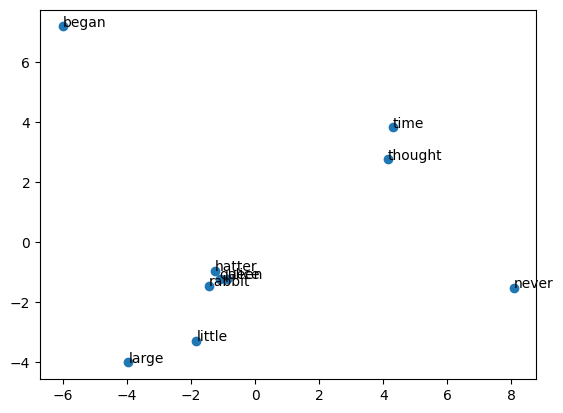

In [67]:
word_similarities(model.wv, term_list)

## Word2Vec Analysis

1. For each term, what similar terms are most pertinent? 

* Alice: razumihin, wendy, and svidrigaïlov (all names)
* Queen: king, am, and farewell
* Rabbit: duchess, jump, and lavender
* Hatter: starkey, krassotkin, and gryphon
* Thought: thought, saying, and knew
* Little: big, small, and bit
* Never: ever, hardly, and probably
* Time: day, moment, and morning
* Began: tried, listened, and started
* Large: small, vast, and huge

2. Which similar terms are least pertinent?  

* Alice: mitya, raskolnikov, and zametov (all names)
* Queen: dragon, steadfast, and novel
* Rabbit: horse, white,and bookkeeper
* Hatter: dormouse, good, and no
* Thought: forgot, dream, and understood
* Little: girl, few, and young
* Never: why, really, and simply
* Time: tale, week, and day
* Began: rushed, returned, and seeming
* Large: broad, wooden, and flame

3. What insights about the structure of the book are represented by the pertinent similar terms?  

I am ignorring the names because I think those aren't important to the structure, so the words that aren't names. The structure of the book can be represented by the terms "tale", "dream", "thought", "queen", "dragon". Those 5 terms would be the best short summarization of the novel if it had to be rated in terms. The similar terms give insight about the whole book's plot and characters through words.

# Summative Analysis

Here is a list of tools we have used in this lab:
* Extractive summarization
  * tf-idf
  * TextRank
* Keyword identification
  * tf-idf
  * TextRank
* Word2Vec

Reflecting on these tools, answer the following questions:

1. What insights do you achieve or patterns did you recognize that you had not previously known?

I didn't know about any of these tools and libraries before I did this lab, so I am walking away with this whith a whole lot. The patterns is that the overall idea of all of them is to give a unit (whether it's paragraph, sentence, or word) a numerical score and then do something with that score (compare similarities to other words, rate sentences, paraphrase things, etc.). So I learned a great amount of stuff in this lab.

2. For each of the five tools listed above, how useful it was to you in gaining new insights?

* Extractive summarization
  * tf-idf: My tf-idf struggled and was a little inaccurate due to unknown errors so that made my life a little tought, but it was cool to see how it made summaries of documents so easily, even though it wasn't the most accurate.
  * TextRank: I found TextRank very cool for summarization because it was an even more in depth version of the tf-idf summarization. The summaries were more accurate than tf-idf and definitely took in more input. I thought it was interesting how it utilized matrices and about 5 other functions to get the results and gaining new insights on summarization. 
* Keyword identification
  * tf-idf: Tf-idf was very cool for Keyword Identifiation, even though it was heavy on the names. It was interesting to see the ratings of words, how frequently they appeared, and also similar words to them. This gives some useful insight on 
  * TextRank: Again, this was a more in depth version of tf-idf because it was more accurate. It takes in more factors, so it is bound to be better. 
* Word2Vec: I did not know this existed. It was very useful for gaining insights because the exercises we performed made us apply what we have learned. We found the top 50 words in our novel and then used Word2Vec to assign bumerical values to these words to find similar words.

3. What applications beyond literary analysis could you envision for these tools?

chatGPT: what words to write in a paper (what words fit best in a paper), search engines, online dictionaries (synonyms in particular), and autocorrect/autofill